In [12]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from time import perf_counter
import gc
import shutil
import subprocess
import threading
import time

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.metrics import average_precision_score, roc_auc_score
from tqdm.auto import tqdm
from transformers import AutoModelForImageTextToText, AutoProcessor
from transformers.models.siglip.configuration_siglip import SiglipVisionConfig
from transformers.models.siglip.modeling_siglip import SiglipMultiheadAttentionPoolingHead

import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

In [39]:
# Constants.

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "benchmark" else Path.cwd()
DATA_CSV = PROJECT_ROOT / "artifacts/processed_data/chexpertplus_frontal_5labels.csv"
LINEAR_METRICS_CSV = PROJECT_ROOT / "artifacts/probing/linear_probe/results/experiment_metrics.csv"
TEMP_CACHE_DIR = PROJECT_ROOT / "temp/mha_activation_cache"
IO_H5 = TEMP_CACHE_DIR / "layer_17_fp32_io_benchmark.h5"

MEDGEMMA_MODEL_ID = "google/medgemma-4b-it"
MODEL_DTYPE = torch.bfloat16
RANDOM_STATE = 42

TARGET_LABELS = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]
BENCHMARK_LABEL = "Pleural Effusion"
BENCHMARK_PROMPT_ORDER = "text_first"
BENCHMARK_LAYERS = [17]

IMAGE_LOAD_NUM_WORKERS = 4
MEDGEMMA_BATCH_SIZE = 24
MHA_BATCH_SIZE = 512
MHA_EPOCHS = 50
MHA_EVAL_EVERY_EPOCHS = 10
MHA_LEARNING_RATE = 5e-5
MHA_WEIGHT_DECAY = 1e-4
MHA_NUM_HEADS = 20
MHA_MLP_DIM = 10240
MHA_IO_LAYER = 17
HDF5_IO_CHUNK_ROWS = 16
DELETE_IO_BENCHMARK_FILE = True
PROBE_INNER_NUM_THREADS = 8

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

TEMP_CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# Small utilities for loading images and printing resource usage.

def load_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB").copy()


def process_rss_gb():
    status_path = Path("/proc/self/status")
    if not status_path.exists():
        return np.nan
    for line in status_path.read_text().splitlines():
        if line.startswith("VmRSS:"):
            return float(line.split()[1]) / 1024**2
    return np.nan


def system_ram_gb():
    meminfo_path = Path("/proc/meminfo")
    if not meminfo_path.exists():
        return {"system_ram_used_gb": np.nan, "system_ram_free_gb": np.nan}
    vals = {}
    for line in meminfo_path.read_text().splitlines():
        key, value = line.split(":", 1)
        vals[key] = float(value.split()[0]) / 1024**2
    return {
        "system_ram_used_gb": vals.get("MemTotal", np.nan) - vals.get("MemAvailable", np.nan),
        "system_ram_free_gb": vals.get("MemAvailable", np.nan),
    }


def disk_free_gb(path):
    usage = shutil.disk_usage(path)
    return usage.free / 1024**3


def query_gpu():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used,memory.total", "--format=csv,noheader,nounits"],
            text=True,
        ).strip().splitlines()[0]
        util, mem_used, mem_total = [float(x.strip()) for x in out.split(",")]
        return {"gpu_util_pct": util, "gpu_mem_used_mb": mem_used, "gpu_mem_total_mb": mem_total}
    except Exception:
        return {"gpu_util_pct": np.nan, "gpu_mem_used_mb": np.nan, "gpu_mem_total_mb": np.nan}


class GpuMonitor:
    def __init__(self, interval_sec=5):
        self.interval_sec = interval_sec
        self.rows = []
        self.stop = threading.Event()
        self.thread = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        while not self.stop.is_set():
            self.rows.append(query_gpu())
            time.sleep(self.interval_sec)

    def __enter__(self):
        self.thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.stop.set()
        self.thread.join()

    def summary(self, prefix):
        df = pd.DataFrame(self.rows)
        if df.empty:
            return {f"{prefix}_avg_gpu_util_pct": np.nan, f"{prefix}_max_gpu_util_pct": np.nan, f"{prefix}_max_gpu_mem_mb": np.nan}
        return {
            f"{prefix}_avg_gpu_util_pct": df["gpu_util_pct"].mean(),
            f"{prefix}_max_gpu_util_pct": df["gpu_util_pct"].max(),
            f"{prefix}_max_gpu_mem_mb": df["gpu_mem_used_mb"].max(),
        }


def resource_row():
    row = {"process_rss_gb": process_rss_gb(), "disk_free_gb": disk_free_gb(PROJECT_ROOT)}
    row.update(system_ram_gb())
    row.update(query_gpu())
    return row


In [4]:
# Load data and existing linear-probe metrics.

df = pd.read_csv(DATA_CSV)
labels = (df[TARGET_LABELS].to_numpy() == 1).astype(np.int8)
train_idx = np.where(df["probe_split"].to_numpy() == "train")[0]
test_idx = np.where(df["probe_split"].to_numpy() == "test")[0]
image_paths = df["image_path"].tolist()
label_i = TARGET_LABELS.index(BENCHMARK_LABEL)

linear_metrics = pd.read_csv(LINEAR_METRICS_CSV)
if "model_name" not in linear_metrics.columns:
    linear_metrics["model_name"] = np.where(linear_metrics["feature"].eq("medsiglip_standalone"), "medsiglip_standalone", "base_medgemma")
linear_metrics["layer"] = pd.to_numeric(linear_metrics["layer"], errors="coerce")

comparison_rows = []
medsiglip_df = linear_metrics[(linear_metrics["feature"] == "medsiglip_standalone") & (linear_metrics["label"] == BENCHMARK_LABEL)]
if not medsiglip_df.empty:
    row = medsiglip_df.iloc[0]
    comparison_rows.append({"source": "old_metrics", "probe": "MedSigLIP baseline", "layer": np.nan, "auroc": row["auroc"], "auprc": row["auprc"], "positive_prevalence": row["positive_prevalence"]})

old_linear_df = linear_metrics[
    (linear_metrics["model_name"] == "base_medgemma")
    & (linear_metrics["prompt_order"] == BENCHMARK_PROMPT_ORDER)
    & (linear_metrics["label"] == BENCHMARK_LABEL)
    & (linear_metrics["feature"].isin(["medgemma_layer_mean_image_token", "medgemma_layer_last_image_token"]))
    & (linear_metrics["layer"].isin(BENCHMARK_LAYERS))
]
for _, row in old_linear_df.iterrows():
    comparison_rows.append({
        "source": "old_metrics",
        "probe": row["feature"],
        "layer": int(row["layer"]),
        "auroc": row["auroc"],
        "auprc": row["auprc"],
        "positive_prevalence": row["positive_prevalence"],
    })

print("rows", len(df), "train", len(train_idx), "test", len(test_idx))
print("benchmark", BENCHMARK_PROMPT_ORDER, BENCHMARK_LABEL, BENCHMARK_LAYERS)
display(pd.DataFrame(comparison_rows).sort_values(["layer", "probe"], na_position="first"))
display(pd.DataFrame([resource_row()]))


rows 25000 train 20000 test 5000
benchmark text_first Pleural Effusion [17]


,source,probe,layer,auroc,auprc,positive_prevalence
0,old_metrics,MedSigLIP baseline,NaN,0.849220,0.824452,0.4572
1,old_metrics,medgemma_layer_last_image_token,17.0,0.775222,0.739815,0.4572
2,old_metrics,medgemma_layer_mean_image_token,17.0,0.824099,0.799459,0.4572


,process_rss_gb,disk_free_gb,system_ram_used_gb,system_ram_free_gb,gpu_util_pct,gpu_mem_used_mb,gpu_mem_total_mb
0,0.806808,11330.272785,24.110859,1487.380474,0.0,4.0,143771.0


In [5]:
# Load images into CPU RAM.

t0 = perf_counter()
with ThreadPoolExecutor(max_workers=IMAGE_LOAD_NUM_WORKERS) as pool:
    images = list(tqdm(pool.map(load_rgb, image_paths), total=len(image_paths), desc="Load images"))
image_load_sec = perf_counter() - t0

print("cached images", len(images), "image_load_sec", round(image_load_sec, 2))
display(pd.DataFrame([resource_row()]))


Load images: 100%|██████████| 25000/25000 [08:08<00:00, 51.16it/s]


cached images 25000 image_load_sec 489.22


,process_rss_gb,disk_free_gb,system_ram_used_gb,system_ram_free_gb,gpu_util_pct,gpu_mem_used_mb,gpu_mem_total_mb
0,652.315197,11330.272785,677.092567,834.398766,0.0,4.0,143771.0


In [6]:
# Load MedGemma processor and cache processed pixel_values.

medgemma_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)

pixel_chunks = []
t0 = perf_counter()
for start in tqdm(range(0, len(images), MEDGEMMA_BATCH_SIZE), desc="MedGemma image processor"):
    end = min(start + MEDGEMMA_BATCH_SIZE, len(images))
    pixel_inputs = medgemma_processor.image_processor(images=images[start:end], return_tensors="pt", do_pan_and_scan=False)
    pixel_chunks.append(pixel_inputs["pixel_values"].to(dtype=MODEL_DTYPE, device="cpu"))
medgemma_pixel_values = torch.cat(pixel_chunks, dim=0)
image_process_sec = perf_counter() - t0
del pixel_chunks, images
gc.collect()

print("cached pixel_values", tuple(medgemma_pixel_values.shape), medgemma_pixel_values.dtype)
print("deleted PIL image cache")
print("image_process_sec", round(image_process_sec, 2))
display(pd.DataFrame([resource_row()]))


MedGemma image processor: 100%|██████████| 1042/1042 [25:15<00:00,  1.45s/it] 


cached pixel_values (25000, 3, 896, 896) torch.bfloat16
deleted PIL image cache
image_process_sec 1559.94


,process_rss_gb,disk_free_gb,system_ram_used_gb,system_ram_free_gb,gpu_util_pct,gpu_mem_used_mb,gpu_mem_total_mb
0,781.296883,11330.272781,809.776726,701.714607,0.0,4.0,143771.0


In [7]:
# Prompt/token helpers.

def prompt_text(prompt_order, label):
    question = f"Question: Is there {label.lower()} in this image? Answer yes or no."
    image_item = {"type": "image"}
    if prompt_order == "image_first":
        content = [image_item, {"type": "text", "text": f"\n{question}\nAnswer: "}]
    else:
        content = [{"type": "text", "text": f"{question}\n"}, image_item, {"type": "text", "text": "\nAnswer: "}]
    messages = [{"role": "user", "content": content}]
    text = medgemma_processor.apply_chat_template(messages, add_generation_prompt=False, tokenize=False)
    if isinstance(text, list):
        text = text[0]
    return text.replace(medgemma_processor.boi_token, medgemma_processor.full_image_sequence)


def tokenize_prompt(prompt_order, label, batch_size):
    inputs = medgemma_processor.tokenizer(
        [prompt_text(prompt_order, label)] * batch_size,
        return_tensors="pt",
        padding=True,
    )
    if hasattr(medgemma_processor, "create_mm_token_type_ids"):
        token_type_ids = medgemma_processor.create_mm_token_type_ids(inputs["input_ids"])
        if not torch.is_tensor(token_type_ids):
            token_type_ids = torch.tensor(token_type_ids)
        inputs["token_type_ids"] = token_type_ids
    return inputs


In [8]:
# Run base MedGemma once and cache selected layer image-token activations in RAM.

device = "cuda" if torch.cuda.is_available() else "cpu"
medgemma_model = AutoModelForImageTextToText.from_pretrained(MEDGEMMA_MODEL_ID, dtype=MODEL_DTYPE, device_map="auto").eval()
model_device = next(medgemma_model.parameters()).device
model_config = medgemma_model.config
num_layers = model_config.text_config.num_hidden_layers
hidden_size = model_config.text_config.hidden_size
image_token_id = getattr(model_config, "image_token_id", None)
if image_token_id is None:
    image_token_id = getattr(model_config, "image_token_index")

check_inputs = tokenize_prompt(BENCHMARK_PROMPT_ORDER, BENCHMARK_LABEL, 1)
image_token_count = int(check_inputs["input_ids"].eq(image_token_id).sum().item())
layer_caches = {
    layer: torch.empty((len(df), image_token_count, hidden_size), dtype=MODEL_DTYPE, device="cpu")
    for layer in BENCHMARK_LAYERS
}

print("num_layers", num_layers, "hidden_size", hidden_size, "image_token_count", image_token_count)
print("cache per layer gb", layer_caches[BENCHMARK_LAYERS[0]].numel() * 2 / 1024**3)
print("total selected layer cache gb", sum(x.numel() * 2 for x in layer_caches.values()) / 1024**3)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

extract_start = perf_counter()
with GpuMonitor() as gpu_monitor:
    for start in tqdm(range(0, len(df), MEDGEMMA_BATCH_SIZE), desc="Extract selected layers"):
        end = min(start + MEDGEMMA_BATCH_SIZE, len(df))
        batch_size = end - start
        inputs = tokenize_prompt(BENCHMARK_PROMPT_ORDER, BENCHMARK_LABEL, batch_size)
        inputs["pixel_values"] = medgemma_pixel_values[start:end]
        inputs = {
            k: v.to(device=model_device, dtype=MODEL_DTYPE) if v.is_floating_point() else v.to(device=model_device)
            for k, v in inputs.items()
        }

        with torch.inference_mode():
            outputs = medgemma_model(
                **inputs,
                output_hidden_states=True,
                use_cache=False,
                logits_to_keep=1,
                return_dict=True,
            )

        image_mask = inputs["input_ids"].eq(image_token_id)
        for layer in BENCHMARK_LAYERS:
            hidden = outputs.hidden_states[layer + 1]
            tokens = hidden[image_mask].reshape(batch_size, image_token_count, hidden_size).detach().to("cpu", dtype=MODEL_DTYPE)
            layer_caches[layer][start:end].copy_(tokens)

        del outputs, inputs

activation_extract_sec = perf_counter() - extract_start
extract_gpu = gpu_monitor.summary("extract")
peak_gpu_gb = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else np.nan

print("activation_extract_sec", round(activation_extract_sec, 2))
print("torch_peak_gpu_gb", round(peak_gpu_gb, 2) if not np.isnan(peak_gpu_gb) else peak_gpu_gb)
display(pd.DataFrame([{**extract_gpu, "activation_extract_sec": activation_extract_sec, "torch_peak_gpu_gb": peak_gpu_gb, **resource_row()}]))


Loading weights: 100%|██████████| 883/883 [00:02<00:00, 324.99it/s]


num_layers 34 hidden_size 2560 image_token_count 256
cache per layer gb 30.517578125
total selected layer cache gb 30.517578125


Extract selected layers: 100%|██████████| 1042/1042 [14:16<00:00,  1.22it/s]


activation_extract_sec 859.73
torch_peak_gpu_gb 10.64


,extract_avg_gpu_util_pct,extract_max_gpu_util_pct,extract_max_gpu_mem_mb,activation_extract_sec,torch_peak_gpu_gb,process_rss_gb,disk_free_gb,system_ram_used_gb,system_ram_free_gb,gpu_util_pct,gpu_mem_used_mb,gpu_mem_total_mb
0,77.08125,100.0,13087.0,859.729249,10.636546,811.974445,11618.91367,839.905758,671.585575,0.0,13087.0,143771.0


In [40]:
# Multi-head attention pooling probe.

class MHAPoolingProbe(torch.nn.Module):
    def __init__(self, hidden_size=2560, intermediate_size=10240, num_attention_heads=20):
        super().__init__()
        cfg = SiglipVisionConfig(
            hidden_size=hidden_size,
            intermediate_size=intermediate_size,
            num_attention_heads=num_attention_heads,
            layer_norm_eps=1e-6,
            hidden_act="gelu_pytorch_tanh",
        )
        self.pooler = SiglipMultiheadAttentionPoolingHead(cfg)
        self.classifier = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):
        pooled = self.pooler(x)
        return self.classifier(pooled).squeeze(-1)


def train_mha_probe(tokens, layer):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    y = torch.tensor(labels[:, label_i], dtype=torch.float32)
    train_indices = torch.tensor(train_idx, dtype=torch.long)
    test_indices = torch.tensor(test_idx, dtype=torch.long)
    y_train = labels[train_idx, label_i]
    y_test = labels[test_idx, label_i]

    probe = MHAPoolingProbe(
        hidden_size=tokens.shape[-1],
        intermediate_size=MHA_MLP_DIM,
        num_attention_heads=MHA_NUM_HEADS,
    ).to(device)

    optimizer = torch.optim.AdamW(
        probe.parameters(),
        lr=MHA_LEARNING_RATE,
        weight_decay=MHA_WEIGHT_DECAY,
    )
    criterion = torch.nn.BCEWithLogitsLoss()

    def predict_scores(indices):
        scores = []
        probe.eval()
        with torch.inference_mode():
            for start in range(0, len(indices), MHA_BATCH_SIZE):
                idx = indices[start:start + MHA_BATCH_SIZE]
                x_batch = tokens[idx].to(device=device, non_blocking=True)
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=device == "cuda"):
                    logits = probe(x_batch)
                scores.append(logits.float().cpu())
        return torch.cat(scores).numpy()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    train_start = perf_counter()
    eval_rows = []

    with GpuMonitor() as gpu_monitor:
        for epoch in range(MHA_EPOCHS):
            perm = train_indices[torch.randperm(len(train_indices))]
            epoch_losses = []
            probe.train()

            for start in range(0, len(perm), MHA_BATCH_SIZE):
                idx = perm[start:start + MHA_BATCH_SIZE]
                x_batch = tokens[idx].to(device=device, non_blocking=True)
                y_batch = y[idx].to(device=device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=device == "cuda"):
                    logits = probe(x_batch)
                loss = criterion(logits.float(), y_batch)
                loss.backward()
                optimizer.step()

                epoch_losses.append(float(loss.detach().cpu()))

            train_loss = float(np.mean(epoch_losses))
            train_auroc = np.nan
            test_auroc = np.nan

            if (epoch + 1) == 1 or (epoch + 1) % MHA_EVAL_EVERY_EPOCHS == 0 or (epoch + 1) == MHA_EPOCHS:
                train_scores = predict_scores(train_indices)
                test_scores = predict_scores(test_indices)
                train_auroc = float(roc_auc_score(y_train, train_scores))
                test_auroc = float(roc_auc_score(y_test, test_scores))
                print("layer", layer, "epoch", epoch + 1, "loss", round(train_loss, 4), "train_auroc", round(train_auroc, 4), "test_auroc", round(test_auroc, 4))
            else:
                print("layer", layer, "epoch", epoch + 1, "loss", round(train_loss, 4))

            eval_rows.append({
                "layer": layer,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_auroc": train_auroc,
                "test_auroc": test_auroc,
            })

        final_test_scores = predict_scores(test_indices)

    train_sec = perf_counter() - train_start
    peak_gpu_gb = torch.cuda.max_memory_allocated() / 1024**3 if torch.cuda.is_available() else np.nan
    best_eval = (
        pd.DataFrame(eval_rows)
        .dropna(subset=["test_auroc"])
        .sort_values("test_auroc", ascending=False)
        .iloc[0]
    )

    del probe, optimizer
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "source": "fresh_mha_benchmark",
        "probe": "mha_pooled_image_token",
        "layer": layer,
        "auroc": float(roc_auc_score(y_test, final_test_scores)),
        "positive_prevalence": float(y_test.mean()),
        "mha_train_sec": train_sec,
        "final_train_loss": eval_rows[-1]["train_loss"],
        "best_epoch": int(best_eval["epoch"]),
        "best_auroc": float(best_eval["test_auroc"]),
        "eval_history": eval_rows,
        "torch_peak_gpu_gb": peak_gpu_gb,
        **gpu_monitor.summary(f"mha_layer_{layer}"),
        **resource_row(),
    }

In [41]:
# Train MHA probes on cached layers and compare with existing linear metrics.

mha_rows = []
history_rows = []

for layer in BENCHMARK_LAYERS:
    print("training MHA layer", layer)
    row = train_mha_probe(layer_caches[layer], layer)
    history_rows.extend(row.pop("eval_history"))
    mha_rows.append(row)

mha_df = pd.DataFrame(mha_rows)
history_df = pd.DataFrame(history_rows)

comparison_df = pd.concat([pd.DataFrame(comparison_rows), mha_df], ignore_index=True, sort=False)

display(history_df)
display(comparison_df.sort_values(["layer", "probe"], na_position="first"))

training MHA layer 17
layer 17 epoch 1 loss 147.2008 train_auroc 0.7113 test_auroc 0.7019
layer 17 epoch 2 loss 41.1234
layer 17 epoch 3 loss 14.252
layer 17 epoch 4 loss 4.2624
layer 17 epoch 5 loss 6.2355
layer 17 epoch 6 loss 4.4371
layer 17 epoch 7 loss 4.3584
layer 17 epoch 8 loss 4.9858
layer 17 epoch 9 loss 6.9879
layer 17 epoch 10 loss 16.6399 train_auroc 0.844 test_auroc 0.8378
layer 17 epoch 11 loss 6.159
layer 17 epoch 12 loss 6.3347
layer 17 epoch 13 loss 3.6276
layer 17 epoch 14 loss 5.4239
layer 17 epoch 15 loss 8.6615
layer 17 epoch 16 loss 9.1227
layer 17 epoch 17 loss 23.676
layer 17 epoch 18 loss 4.7709
layer 17 epoch 19 loss 2.2819
layer 17 epoch 20 loss 13.6426 train_auroc 0.8557 test_auroc 0.849
layer 17 epoch 21 loss 3.0229
layer 17 epoch 22 loss 2.7503
layer 17 epoch 23 loss 10.2649
layer 17 epoch 24 loss 3.3042
layer 17 epoch 25 loss 3.0962
layer 17 epoch 26 loss 2.1805
layer 17 epoch 27 loss 14.6331
layer 17 epoch 28 loss 3.6236
layer 17 epoch 29 loss 2.712
lay

,layer,epoch,train_loss,train_auroc,test_auroc
0,17,1,147.200769,0.711322,0.701947
1,17,2,41.123441,NaN,NaN
2,17,3,14.251975,NaN,NaN
3,17,4,4.262354,NaN,NaN
4,17,5,6.235461,NaN,NaN
5,17,6,4.437119,NaN,NaN
6,17,7,4.358380,NaN,NaN
7,17,8,4.985775,NaN,NaN
8,17,9,6.987949,NaN,NaN
9,17,10,16.639869,0.843953,0.837811


,source,probe,layer,auroc,auprc,positive_prevalence,mha_train_sec,final_train_loss,best_epoch,best_auroc,...,mha_layer_17_avg_gpu_util_pct,mha_layer_17_max_gpu_util_pct,mha_layer_17_max_gpu_mem_mb,process_rss_gb,disk_free_gb,system_ram_used_gb,system_ram_free_gb,gpu_util_pct,gpu_mem_used_mb,gpu_mem_total_mb
0,old_metrics,MedSigLIP baseline,NaN,0.849220,0.824452,0.4572,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,old_metrics,medgemma_layer_last_image_token,17.0,0.775222,0.739815,0.4572,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,old_metrics,medgemma_layer_mean_image_token,17.0,0.824099,0.799459,0.4572,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fresh_mha_benchmark,mha_pooled_image_token,17.0,0.846905,NaN,0.4572,282.352579,2.892754,30.0,0.851231,...,36.584906,48.0,16671.0,811.313995,11617.688873,837.111057,674.380276,0.0,10907.0,143771.0


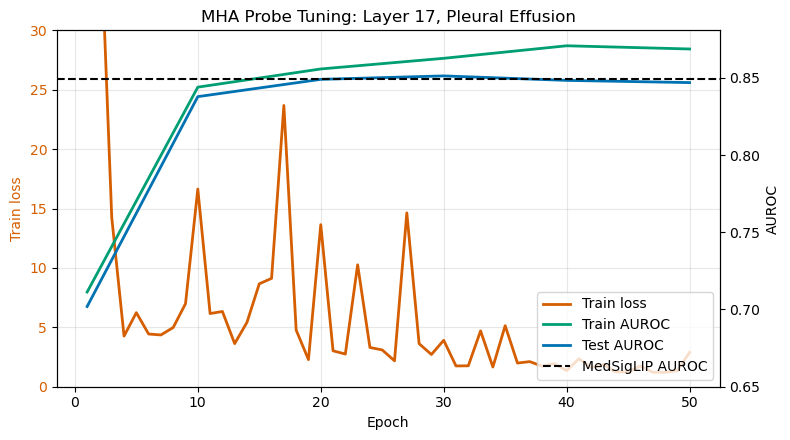

In [42]:
# Plot MHA train loss and train/test AUROC from the latest tuning run.

history_df = pd.DataFrame(history_rows)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    color="#D55E00",
    linewidth=2,
    label="Train loss",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="#D55E00")
ax1.set_ylim(0, 30)
ax1.tick_params(axis="y", labelcolor="#D55E00")
ax1.grid(True, alpha=0.3)

metric_df = history_df.dropna(subset=["test_auroc"])

ax2 = ax1.twinx()
ax2.plot(
    metric_df["epoch"],
    metric_df["train_auroc"],
    color="#009E73",
    linewidth=2,
    label="Train AUROC",
)
ax2.plot(
    metric_df["epoch"],
    metric_df["test_auroc"],
    color="#0072B2",
    linewidth=2,
    label="Test AUROC",
)
ax2.axhline(
    0.849220,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="MedSigLIP AUROC",
)
ax2.set_ylabel("AUROC")
ax2.set_ylim(0.65, max(0.87, metric_df[["train_auroc", "test_auroc"]].max().max() + 0.01))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.title("MHA Probe Tuning: Layer 17, Pleural Effusion")
plt.tight_layout()
plt.show()

In [11]:
# # Separate HDF5 disk I/O benchmark for one cached layer saved as fp32.

# tokens = layer_caches[MHA_IO_LAYER]
# if IO_H5.exists():
#     IO_H5.unlink()

# write_start = perf_counter()
# with h5py.File(IO_H5, "w") as h5:
#     dset = h5.create_dataset(
#         "image_tokens",
#         shape=tuple(tokens.shape),
#         dtype="float32",
#         chunks=(HDF5_IO_CHUNK_ROWS, tokens.shape[1], tokens.shape[2]),
#     )
#     for start in tqdm(range(0, len(tokens), HDF5_IO_CHUNK_ROWS), desc="Write HDF5 fp32"):
#         end = min(start + HDF5_IO_CHUNK_ROWS, len(tokens))
#         dset[start:end] = tokens[start:end].float().numpy()
#     h5.flush()
# write_sec = perf_counter() - write_start
# file_size_gb = IO_H5.stat().st_size / 1024**3

# read_buffer = torch.empty_like(tokens)
# read_start = perf_counter()
# with h5py.File(IO_H5, "r") as h5:
#     dset = h5["image_tokens"]
#     for start in tqdm(range(0, len(tokens), HDF5_IO_CHUNK_ROWS), desc="Read HDF5 fp32"):
#         end = min(start + HDF5_IO_CHUNK_ROWS, len(tokens))
#         read_buffer[start:end].copy_(torch.from_numpy(dset[start:end]).to(dtype=MODEL_DTYPE))
# read_sec = perf_counter() - read_start

# del read_buffer
# if DELETE_IO_BENCHMARK_FILE:
#     IO_H5.unlink()

# io_df = pd.DataFrame([{
#     "layer": MHA_IO_LAYER,
#     "file_size_gb": file_size_gb,
#     "write_sec": write_sec,
#     "write_gb_per_sec": file_size_gb / write_sec,
#     "read_sec": read_sec,
#     "read_gb_per_sec": file_size_gb / read_sec,
#     "deleted_file": DELETE_IO_BENCHMARK_FILE,
#     **resource_row(),
# }])
# display(io_df)
